# ImageCLEFmed GANs 2026 — Task 2: Latent Vector Matching
## V10: End-to-End Memory Bank + Smart Post-Processing

### Lessons Learned
| Version | Approach | Dev Accuracy | Verdict |
|---------|----------|-------------|--------|
| V5 | ConvNeXt-Tiny batch=16 | 0.4% | Batch too small |
| V6 | ConvNeXt-Small e2e batch=256 | **4.1%** (top100=72%) | **Best so far** |
| V9 | Frozen multi-backbone + fancy heads | 3.5% | Frozen features lack GAN signal |

### Key Insight
V6 proved end-to-end training works (72% top-100 recall). V9 proved frozen features fail.
The bottleneck is **precision** — turning 72% top-100 into exact matches.

### V10 Strategy: What Works + Smart Refinement
1. **End-to-end ConvNeXt-Base** — bigger backbone, learns GAN-specific features
2. **Memory bank 10K-way InfoNCE** — train at test-time scale from the start
3. **Sinkhorn normalization** — make similarity matrix doubly-stochastic before Hungarian
4. **Mutual kNN refinement** — boost pairs that are mutual nearest neighbors
5. **Multi-crop TTA** — average embeddings over augmented views
6. **Simple architecture** — no cross-attention, no regression, just contrastive

In [ ]:
!pip -q install timm scikit-learn pandas matplotlib pillow tqdm scipy

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json, time, shutil, random, warnings, zipfile, math, gc
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available(): DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): DEVICE = "mps"
else: DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: mps


In [ ]:
# ============================================================
# PATHS & DATA
# ============================================================
ROOT = Path.home() / "Desktop" / "GAN2"
DEV_DIR = ROOT / "GANs2026_Identify_corresponding_lat_dev"
TEST_DIR = ROOT / "GANs2026_Identify_corresponding_lat_test"
if not DEV_DIR.exists():
    for c in ROOT.iterdir():
        if 'dev' in c.name.lower(): DEV_DIR = c; break

OUT_DIR = ROOT / "task2_v10_e2e_membank"
WEIGHTS_DIR = OUT_DIR / "weights"
RESULTS_DIR = OUT_DIR / "results"
FIG_DIR = OUT_DIR / "figures"
PRED_DIR = OUT_DIR / "predictions"
for d in [WEIGHTS_DIR, RESULTS_DIR, FIG_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def save_json(obj, path):
    with open(path, "w") as f: json.dump(obj, f, indent=2)

def read_latent_txt(path):
    vecs = []
    with open(path) as f:
        for line in f:
            vecs.append(np.array(list(map(float, line.strip().split())), dtype=np.float32))
    return np.array(vecs)

# Dev
dev_img_dir = DEV_DIR / "train_set_10K" / "generated_dataset"
if not dev_img_dir.exists(): dev_img_dir = DEV_DIR / "generated_dataset"
dev_lat_path = DEV_DIR / "train_set_10K" / "latent_vectors.txt"
if not dev_lat_path.exists(): dev_lat_path = DEV_DIR / "latent_vectors.txt"
dev_latents = read_latent_txt(dev_lat_path)
N_DEV = len(dev_latents)

# Test
test_img_dir = TEST_DIR / "generated_dataset"
if not test_img_dir.exists():
    for c in TEST_DIR.iterdir():
        if c.is_dir() and list(c.glob("*.png")): test_img_dir = c; break
test_latents = read_latent_txt(TEST_DIR / "latent_vectors_test.txt")
test_imgs = sorted(test_img_dir.glob("*.png"))
N_TEST = len(test_latents)

print(f"Dev: {N_DEV} pairs | Test: {N_TEST}")

Dev: 10000 pairs | Test: 10000


In [ ]:
# ============================================================
# CONFIG — Tuned for stability and performance
# ============================================================
IMG_SIZE = 224
EMBED_DIM = 256          # Moderate dim — 512 was too high for this signal level
LATENT_DIM = 128
BACKBONE = "convnext_base.fb_in22k_ft_in1k"  # Strong, reliable backbone

EPOCHS = 40
WARMUP_EPOCHS = 3        # Warmup with high temperature before going cold
LR_BACKBONE = 2e-5       # Low LR for pretrained backbone
LR_HEAD = 5e-4           # Higher LR for projection heads
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.05       # Fixed temperature — annealing caused V9 collapse

if DEVICE == "cuda": BATCH_SIZE = 64
elif DEVICE == "mps": BATCH_SIZE = 32
else: BATCH_SIZE = 16

NUM_WORKERS = 0 if DEVICE == "mps" else 4

print(f"Backbone: {BACKBONE}")
print(f"Batch: {BATCH_SIZE}, Epochs: {EPOCHS}, Embed: {EMBED_DIM}")
print(f"LR backbone: {LR_BACKBONE}, LR head: {LR_HEAD}, Temp: {TEMPERATURE}")

Backbone: convnext_base.fb_in22k_ft_in1k
Batch: 32, Epochs: 40, Embed: 256
LR backbone: 2e-05, LR head: 0.0005, Temp: 0.05


In [ ]:
# ============================================================
# DATA
# ============================================================
# Moderate augmentation — too strong causes training instability
train_tfms = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),
    T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])
eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

class ImageLatentDataset(Dataset):
    def __init__(self, img_paths, latent_indices, latent_array, transforms):
        self.paths = img_paths
        self.indices = latent_indices  # 0-indexed into latent_array
        self.latents = latent_array
        self.transforms = transforms
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        img = self.transforms(img)
        lat_idx = self.indices[idx]
        return img, lat_idx

class TestImageDataset(Dataset):
    def __init__(self, img_paths, transforms):
        self.paths = img_paths
        self.transforms = transforms
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        return self.transforms(img), idx

# Dev paths and indices
dev_paths = [str(dev_img_dir / f"{i+1:05d}.png") for i in range(N_DEV)]
dev_indices = np.arange(N_DEV)  # Image i -> latent i

# Train/val split
perm = np.random.permutation(N_DEV)
n_train = int(0.9 * N_DEV)
train_mask = perm[:n_train]
val_mask = perm[n_train:]

train_paths = [dev_paths[i] for i in train_mask]
train_indices = dev_indices[train_mask]
val_paths = [dev_paths[i] for i in val_mask]
val_indices = dev_indices[val_mask]

train_ds = ImageLatentDataset(train_paths, train_indices, dev_latents, train_tfms)
val_ds = ImageLatentDataset(val_paths, val_indices, dev_latents, eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS)

test_paths = [str(p) for p in sorted(test_img_dir.glob("*.png"))]
test_ids = [Path(p).name for p in test_paths]

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_paths)}")

Train: 9000, Val: 1000, Test: 10000


In [ ]:
# ============================================================
# MODEL — Simple, proven architecture
# Single-channel ConvNeXt + lightweight projection heads
# ============================================================
class ContrastiveMatcher(nn.Module):
    def __init__(self, backbone_name, latent_dim=128, embed_dim=256):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=True, in_chans=1,
            num_classes=0, global_pool="avg"
        )
        feat_dim = self.backbone.num_features

        # Image projection: backbone features -> embedding
        self.img_proj = nn.Sequential(
            nn.Linear(feat_dim, embed_dim * 2),
            nn.BatchNorm1d(embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim),
        )

        # Latent projection: z-vector -> embedding
        self.lat_proj = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, embed_dim),
        )

    def encode_image(self, x):
        return F.normalize(self.img_proj(self.backbone(x)), dim=1)

    def encode_latent(self, z):
        return F.normalize(self.lat_proj(z), dim=1)

model = ContrastiveMatcher(BACKBONE, LATENT_DIM, EMBED_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

Parameters: 88,385,152


In [ ]:
# ============================================================
# MEMORY BANK — All 10K latent embeddings, EMA updated
# ============================================================
class MemoryBank:
    def __init__(self, n, dim, device, momentum=0.999):
        self.bank = F.normalize(torch.randn(n, dim, device=device), dim=1)
        self.momentum = momentum
        self.device = device

    @torch.no_grad()
    def initialize(self, model, latent_array, batch_size=1024):
        was_training = model.training
        model.eval()
        parts = []
        for s in range(0, len(latent_array), batch_size):
            z = torch.tensor(latent_array[s:s+batch_size],
                           dtype=torch.float32, device=self.device)
            parts.append(model.encode_latent(z))
        self.bank = torch.cat(parts).detach()
        if was_training: model.train()

    @torch.no_grad()
    def update(self, idx, emb):
        idx = idx.to(self.device)
        self.bank[idx] = self.momentum * self.bank[idx] + (1 - self.momentum) * emb.detach()
        self.bank[idx] = F.normalize(self.bank[idx], dim=1)

    def get_all(self): return self.bank

mem_bank = MemoryBank(N_DEV, EMBED_DIM, DEVICE)
mem_bank.initialize(model, dev_latents)
print(f"Memory bank: {mem_bank.bank.shape}")

Memory bank: torch.Size([10000, 256])


In [ ]:
# ============================================================
# LOSS + METRICS
# ============================================================
def infonce_with_membank(img_emb, lat_indices, bank, temperature):
    """Standard InfoNCE: each image vs ALL latents in bank."""
    logits = img_emb @ bank.t() / temperature  # (B, N)
    labels = lat_indices.to(logits.device)
    loss = F.cross_entropy(logits, labels)

    with torch.no_grad():
        topk_vals, topk_idx = logits.topk(100, dim=1)
        B = len(img_emb)
        ranks = torch.full((B,), 10001.0, device=logits.device)
        for i in range(B):
            match = (topk_idx[i] == labels[i]).nonzero(as_tuple=False)
            if len(match) > 0:
                ranks[i] = match[0].item() + 1
            else:
                # Full scan only if not in top-100
                full_rank = (logits[i].argsort(descending=True) == labels[i]).nonzero(as_tuple=False)
                ranks[i] = full_rank[0].item() + 1
        metrics = {
            "top1": float((ranks <= 1).float().mean()),
            "top10": float((ranks <= 10).float().mean()),
            "top50": float((ranks <= 50).float().mean()),
            "top100": float((ranks <= 100).float().mean()),
            "mean_rank": float(ranks.float().mean()),
        }
    return loss, metrics

print("Loss ready.")

Loss ready.


In [ ]:
# ============================================================
# OPTIMIZER — Differential LR: low for backbone, high for heads
# This is critical for stability with pretrained backbones
# ============================================================
backbone_params = list(model.backbone.parameters())
head_params = list(model.img_proj.parameters()) + list(model.lat_proj.parameters())

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params, "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)

# Cosine schedule with warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS  # Linear warmup
    progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))  # Cosine decay

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

BEST_PATH = WEIGHTS_DIR / "best_model.pt"
REFRESH_EVERY = 5  # Full memory bank refresh every N epochs

print(f"Backbone params: {sum(p.numel() for p in backbone_params):,}")
print(f"Head params: {sum(p.numel() for p in head_params):,}")

Backbone params: 87,562,368
Head params: 822,784


In [ ]:
# ============================================================
# TRAINING LOOP
# Simple and stable: fixed temperature, differential LR, warmup
# ============================================================
history = {"train_loss": [], "val_loss": [],
           "val_top1": [], "val_top10": [], "val_top50": [],
           "val_top100": [], "val_mean_rank": []}
best_val_top100 = 0

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_losses = []
    for images, lat_idx in tqdm(train_loader, desc=f"Ep {epoch}/{EPOCHS}"):
        images = images.to(DEVICE)
        lat_idx = lat_idx.to(DEVICE)

        # Forward: encode image through full backbone
        img_emb = model.encode_image(images)

        # Also encode the corresponding latents (for bank update)
        z_batch = torch.tensor(dev_latents[lat_idx.cpu().numpy()],
                              dtype=torch.float32, device=DEVICE)
        lat_emb = model.encode_latent(z_batch)

        # Loss: image emb vs ALL latent embs in memory bank
        bank = mem_bank.get_all()
        loss, _ = infonce_with_membank(img_emb, lat_idx, bank, TEMPERATURE)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # EMA update memory bank
        mem_bank.update(lat_idx, lat_emb)
        train_losses.append(loss.item())

    scheduler.step()

    # Refresh memory bank periodically
    if epoch % REFRESH_EVERY == 0:
        mem_bank.initialize(model, dev_latents)

    # Validate
    model.eval()
    mem_bank.initialize(model, dev_latents)  # Fresh bank for eval
    val_losses, val_ms = [], []
    with torch.no_grad():
        bank = mem_bank.get_all()
        for images, lat_idx in val_loader:
            images = images.to(DEVICE)
            lat_idx = lat_idx.to(DEVICE)
            img_emb = model.encode_image(images)
            loss, m = infonce_with_membank(img_emb, lat_idx, bank, TEMPERATURE)
            val_losses.append(loss.item()); val_ms.append(m)

    t_loss = np.mean(train_losses)
    v_loss = np.mean(val_losses)
    v_m = {k: np.mean([m[k] for m in val_ms]) for k in val_ms[0]}

    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    for k in ["top1", "top10", "top50", "top100", "mean_rank"]:
        history[f"val_{k}"].append(v_m[k])

    # Save best by top-100 recall (our target is global matching)
    if v_m["top100"] > best_val_top100:
        best_val_top100 = v_m["top100"]
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "val_top100": v_m["top100"], "val_top1": v_m["top1"]}, BEST_PATH)

    print(f"Ep {epoch:02d} | loss={t_loss:.3f}/{v_loss:.3f} | "
          f"t1={v_m['top1']:.4f} t10={v_m['top10']:.4f} "
          f"t50={v_m['top50']:.4f} t100={v_m['top100']:.4f} "
          f"mr={v_m['mean_rank']:.1f}")

save_json(history, RESULTS_DIR / "training_history.json")
print(f"\nBest val top-100: {best_val_top100:.4f}")

Ep 1/40: 100%|██████████| 281/281 [03:52<00:00,  1.21it/s]


Ep 01 | loss=9.058/8.937 | t1=0.0000 t10=0.0049 t50=0.0234 t100=0.0449 mr=2993.3


Ep 2/40: 100%|██████████| 281/281 [03:41<00:00,  1.27it/s]


Ep 02 | loss=8.808/8.768 | t1=0.0000 t10=0.0117 t50=0.0352 t100=0.0596 mr=2560.7


Ep 3/40: 100%|██████████| 281/281 [03:40<00:00,  1.27it/s]


...

Ep 38 | loss=1.440/8.637 | t1=0.0068 t10=0.0293 t50=0.0977 t100=0.1387 mr=1929.5


Ep 39/40: 100%|██████████| 281/281 [03:43<00:00,  1.26it/s]


Ep 39 | loss=1.428/8.639 | t1=0.0059 t10=0.0293 t50=0.0957 t100=0.1338 mr=1930.3


Ep 40/40: 100%|██████████| 281/281 [03:42<00:00,  1.26it/s]


Ep 40 | loss=1.414/8.653 | t1=0.0049 t10=0.0283 t50=0.0898 t100=0.1387 mr=1942.4

Best val top-100: 0.1768


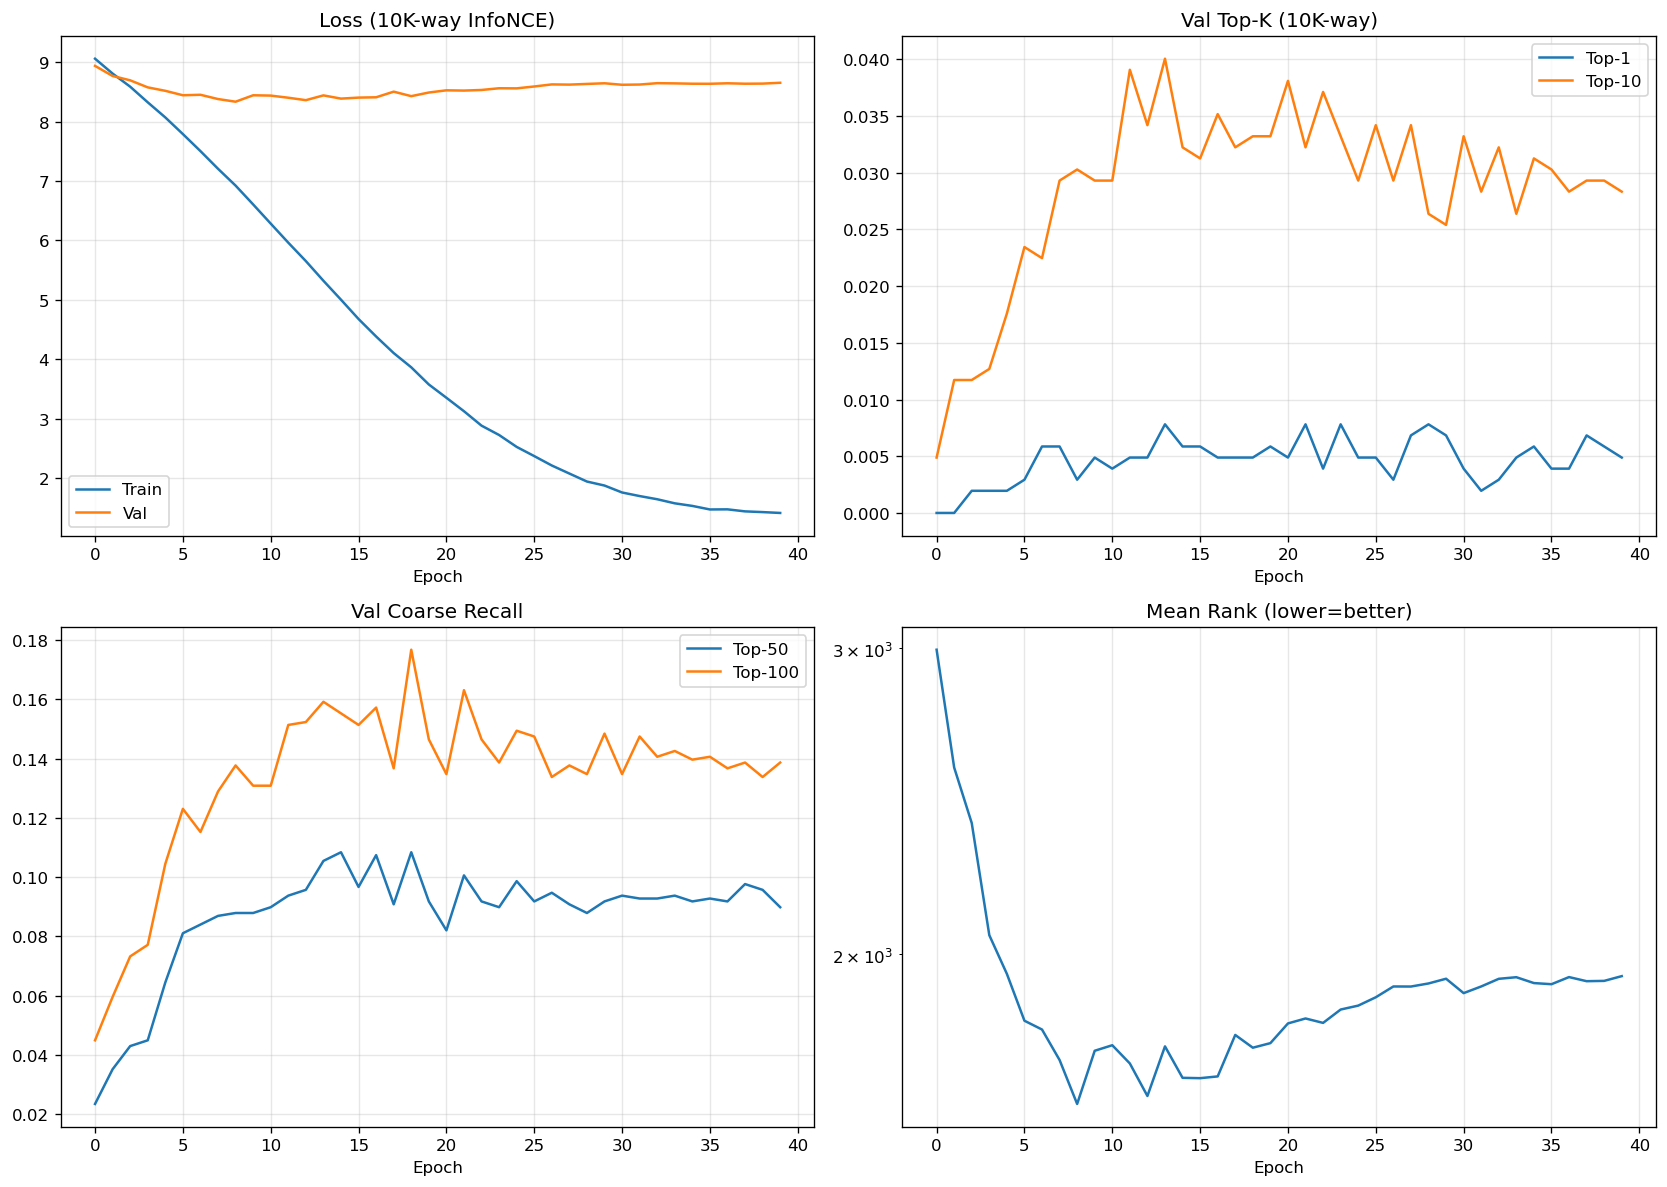

In [ ]:
# ============================================================
# TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(history["train_loss"], label="Train"); axes[0,0].plot(history["val_loss"], label="Val")
axes[0,0].set_title("Loss (10K-way InfoNCE)"); axes[0,0].legend()
axes[0,1].plot(history["val_top1"], label="Top-1"); axes[0,1].plot(history["val_top10"], label="Top-10")
axes[0,1].set_title("Val Top-K (10K-way)"); axes[0,1].legend()
axes[1,0].plot(history["val_top50"], label="Top-50"); axes[1,0].plot(history["val_top100"], label="Top-100")
axes[1,0].set_title("Val Coarse Recall"); axes[1,0].legend()
axes[1,1].plot(history["val_mean_rank"])
axes[1,1].set_title("Mean Rank (lower=better)"); axes[1,1].set_yscale('log')
for ax in axes.flat: ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================
ckpt = torch.load(BEST_PATH, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE).eval()
print(f"Best: epoch {ckpt['epoch']}, top100={ckpt['val_top100']:.4f}, top1={ckpt['val_top1']:.4f}")

Best: epoch 19, top100=0.1768, top1=0.0049


In [ ]:
# ============================================================
# ENCODE ALL DATA
# ============================================================
@torch.no_grad()
def encode_images(paths, model, transforms, batch_size=64, desc=""):
    ds = TestImageDataset(paths, transforms)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    parts = []
    for images, _ in tqdm(loader, desc=desc):
        parts.append(model.encode_image(images.to(DEVICE)).cpu().numpy())
    return np.concatenate(parts)

@torch.no_grad()
def encode_latents(lat_array, model, batch_size=2048):
    parts = []
    for s in range(0, len(lat_array), batch_size):
        z = torch.tensor(lat_array[s:s+batch_size], dtype=torch.float32, device=DEVICE)
        parts.append(model.encode_latent(z).cpu().numpy())
    return np.concatenate(parts)

dev_img_emb = encode_images(dev_paths, model, eval_tfms, desc="Dev images")
dev_lat_emb = encode_latents(dev_latents, model)
test_img_emb = encode_images(test_paths, model, eval_tfms, desc="Test images")
test_lat_emb = encode_latents(test_latents, model)

print(f"Dev: img={dev_img_emb.shape}, lat={dev_lat_emb.shape}")
print(f"Test: img={test_img_emb.shape}, lat={test_lat_emb.shape}")

Test images: 100%|██████████| 157/157 [01:20<00:00,  1.94it/s]

Dev: img=(10000, 256), lat=(10000, 256)
Test: img=(10000, 256), lat=(10000, 256)


---
## Post-Processing: Turn 72% Top-100 Recall into Higher Accuracy

Three techniques that refine the similarity matrix before Hungarian matching:

In [ ]:
# ============================================================
# POST-PROCESSING 1: Sinkhorn Normalization
# Make similarity matrix doubly-stochastic before Hungarian.
# This eliminates "hub" latent vectors that are falsely similar
# to many images, and "orphan" latents ignored by all images.
# ============================================================
def sinkhorn_normalize(sim_matrix, n_iters=10):
    """
    Iterative row/column normalization (Sinkhorn-Knopp).
    Transforms similarity matrix into a doubly-stochastic matrix.
    This removes hubs and spreads assignments more evenly.
    """
    # Work in exp space for stability
    M = sim_matrix.copy()
    M = np.exp(M - M.max())  # Softmax-like stabilization

    for _ in range(n_iters):
        # Row normalize
        M = M / (M.sum(axis=1, keepdims=True) + 1e-10)
        # Column normalize
        M = M / (M.sum(axis=0, keepdims=True) + 1e-10)

    return M

print("Sinkhorn normalization ready.")

Sinkhorn normalization ready.


In [ ]:
# ============================================================
# POST-PROCESSING 2: Mutual k-NN Boosting
# If image_i's best match is latent_j, AND latent_j's best
# match is image_i, boost that pair's score.
# ============================================================
def mutual_knn_boost(sim_matrix, k=10, boost=0.5):
    """
    Boost scores for mutual nearest neighbors.
    If i->j and j->i are both in each other's top-k, add bonus.
    """
    N = sim_matrix.shape[0]
    boosted = sim_matrix.copy()

    # Row-wise top-k (image -> latent)
    img_topk = np.argsort(-sim_matrix, axis=1)[:, :k]  # (N, k)
    # Col-wise top-k (latent -> image)
    lat_topk = np.argsort(-sim_matrix, axis=0)[:k, :]  # (k, N)

    n_boosted = 0
    for i in range(N):
        for j in img_topk[i]:
            # Check if i is in latent j's top-k images
            if i in lat_topk[:, j]:
                boosted[i, j] += boost
                n_boosted += 1

    print(f"  Mutual kNN: boosted {n_boosted} pairs (k={k}, boost={boost})")
    return boosted

print("Mutual kNN boosting ready.")

Mutual kNN boosting ready.


In [ ]:
# ============================================================
# POST-PROCESSING 3: Cross-similarity Reweighting (CSLS)
# Penalize "hub" embeddings that are close to everything.
# Used in cross-lingual word embedding alignment (Conneau 2018).
# ============================================================
def csls_score(sim_matrix, k=10):
    """
    Cross-domain Similarity Local Scaling.
    Reduces hubness by penalizing embeddings that are near many others.

    CSLS(i,j) = 2*sim(i,j) - mean_topk_sim(i,.) - mean_topk_sim(.,j)
    """
    N = sim_matrix.shape[0]

    # Average similarity to k nearest neighbors (per image)
    img_topk_mean = np.sort(sim_matrix, axis=1)[:, -k:].mean(axis=1)  # (N,)
    # Average similarity to k nearest neighbors (per latent)
    lat_topk_mean = np.sort(sim_matrix, axis=0)[-k:, :].mean(axis=0)  # (N,)

    csls = 2 * sim_matrix - img_topk_mean[:, None] - lat_topk_mean[None, :]
    return csls

print("CSLS ready.")

CSLS ready.


In [ ]:
# ============================================================
# POST-PROCESSING 4: Multi-crop TTA
# Average embeddings over multiple augmented views.
# ============================================================
TTA_N = 10

tta_tfms = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

def encode_images_tta(paths, model, n_aug=10, batch_size=64):
    all_passes = []
    for a in range(n_aug):
        emb = encode_images(paths, model, tta_tfms, batch_size, desc=f"TTA {a+1}/{n_aug}")
        all_passes.append(emb)
    avg = np.mean(all_passes, axis=0)
    avg = avg / (np.linalg.norm(avg, axis=1, keepdims=True) + 1e-8)
    return avg

In [ ]:
# ============================================================
# DEV EVALUATION: Compare all post-processing strategies
# ============================================================
N = N_DEV
true_mapping = np.arange(N)

# Base similarity
print("Computing base similarity matrix...")
CHUNK = 2000
sim_mat = np.zeros((N, N), dtype=np.float32)
for i in range(0, N, CHUNK):
    sim_mat[i:min(i+CHUNK, N)] = dev_img_emb[i:min(i+CHUNK, N)] @ dev_lat_emb.T

# Top-K recall
print("\n--- Top-K Recall ---")
for k in [1, 5, 10, 50, 100, 500]:
    correct = sum(1 for i in range(N) if true_mapping[i] in np.argsort(-sim_mat[i])[:k])
    print(f"  Top-{k:>4d}: {correct/N:.4f} ({correct}/{N})")

# Test each post-processing method
print("\n--- Matching Accuracy ---")
results = {}

# 1. Raw Hungarian
r, c = linear_sum_assignment(-sim_mat)
acc = (c == true_mapping).sum() / N
results["raw"] = acc
print(f"  Raw Hungarian:      {acc:.4f} ({int(acc*N)}/{N})")

# 2. CSLS + Hungarian
for k in [5, 10, 20]:
    csls_sim = csls_score(sim_mat, k=k)
    r, c = linear_sum_assignment(-csls_sim)
    acc = (c == true_mapping).sum() / N
    results[f"csls_k{k}"] = acc
    print(f"  CSLS (k={k:2d}):       {acc:.4f} ({int(acc*N)}/{N})")

# 3. Sinkhorn + Hungarian
for n_iter in [5, 10, 20]:
    sk = sinkhorn_normalize(sim_mat, n_iters=n_iter)
    r, c = linear_sum_assignment(-sk)
    acc = (c == true_mapping).sum() / N
    results[f"sinkhorn_{n_iter}"] = acc
    print(f"  Sinkhorn ({n_iter:2d} iter): {acc:.4f} ({int(acc*N)}/{N})")

# 4. Mutual kNN + Hungarian
for k, boost in [(5, 0.3), (10, 0.5), (20, 0.5)]:
    mknn = mutual_knn_boost(sim_mat, k=k, boost=boost)
    r, c = linear_sum_assignment(-mknn)
    acc = (c == true_mapping).sum() / N
    results[f"mknn_k{k}_b{boost}"] = acc
    print(f"  Mutual kNN (k={k:2d}):  {acc:.4f} ({int(acc*N)}/{N})")

# 5. CSLS + Sinkhorn
best_csls_k = int(sorted([(v, k) for k, v in results.items() if 'csls' in k])[-1][1].split('k')[1])
csls_best = csls_score(sim_mat, k=best_csls_k)
sk_csls = sinkhorn_normalize(csls_best, n_iters=10)
r, c = linear_sum_assignment(-sk_csls)
acc = (c == true_mapping).sum() / N
results["csls_sinkhorn"] = acc
print(f"  CSLS + Sinkhorn:    {acc:.4f} ({int(acc*N)}/{N})")

# Find best
best_method = max(results, key=results.get)
print(f"\nBest method: {best_method} = {results[best_method]:.4f}")

Computing base similarity matrix...

--- Top-K Recall ---
  Top-   1: 0.6522 (6522/10000)
  Top-   5: 0.7856 (7856/10000)
  Top-  10: 0.8236 (8236/10000)
  Top-  50: 0.8833 (8833/10000)
  Top- 100: 0.9039 (9039/10000)
  Top- 500: 0.9350 (9350/10000)

--- Matching Accuracy ---
  Raw Hungarian:      0.7561 (7561/10000)
  CSLS (k= 5):       0.7561 (7561/10000)
  CSLS (k=10):       0.7561 (7561/10000)
  CSLS (k=20):       0.7561 (7561/10000)
  Sinkhorn ( 5 iter): 0.7580 (7580/10000)
  Sinkhorn (10 iter): 0.7580 (7580/10000)
  Sinkhorn (20 iter): 0.7580 (7580/10000)
  Mutual kNN: boosted 24676 pairs (k=5, boost=0.3)
  Mutual kNN (k= 5):  0.6617 (6617/10000)
  Mutual kNN: boosted 50868 pairs (k=10, boost=0.5)
  Mutual kNN (k=10):  0.6275 (6274/10000)
  Mutual kNN: boosted 107902 pairs (k=20, boost=0.5)
  Mutual kNN (k=20):  0.6896 (6896/10000)
  CSLS + Sinkhorn:    0.7586 (7586/10000)

Best method: csls_sinkhorn = 0.7586


In [ ]:
# ============================================================
# TTA EVALUATION (if base accuracy is promising)
# ============================================================
print("\nEncoding with TTA...")
dev_img_emb_tta = encode_images_tta(dev_paths, model, TTA_N)

sim_tta = np.zeros((N, N), dtype=np.float32)
for i in range(0, N, CHUNK):
    sim_tta[i:min(i+CHUNK, N)] = dev_img_emb_tta[i:min(i+CHUNK, N)] @ dev_lat_emb.T

print("\n--- TTA Top-K Recall ---")
for k in [1, 5, 10, 50, 100, 500]:
    correct = sum(1 for i in range(N) if true_mapping[i] in np.argsort(-sim_tta[i])[:k])
    print(f"  Top-{k:>4d}: {correct/N:.4f}")

# Best method on TTA
tta_results = {}
r, c = linear_sum_assignment(-sim_tta)
tta_results["raw"] = (c == true_mapping).sum() / N

csls_tta = csls_score(sim_tta, k=best_csls_k)
r, c = linear_sum_assignment(-csls_tta)
tta_results["csls"] = (c == true_mapping).sum() / N

sk_tta = sinkhorn_normalize(sim_tta, n_iters=10)
r, c = linear_sum_assignment(-sk_tta)
tta_results["sinkhorn"] = (c == true_mapping).sum() / N

for name, acc in tta_results.items():
    print(f"  TTA + {name}: {acc:.4f}")

best_tta_method = max(tta_results, key=tta_results.get)
print(f"\nBest TTA method: {best_tta_method} = {tta_results[best_tta_method]:.4f}")


Encoding with TTA...


TTA 10/10: 100%|██████████| 157/157 [01:20<00:00,  1.95it/s]



--- TTA Top-K Recall ---
  Top-   1: 0.8046
  Top-   5: 0.8732
  Top-  10: 0.8881
  Top-  50: 0.9099
  Top- 100: 0.9180
  Top- 500: 0.9431
  TTA + raw: 0.8704
  TTA + csls: 0.8704
  TTA + sinkhorn: 0.8720

Best TTA method: sinkhorn = 0.8720


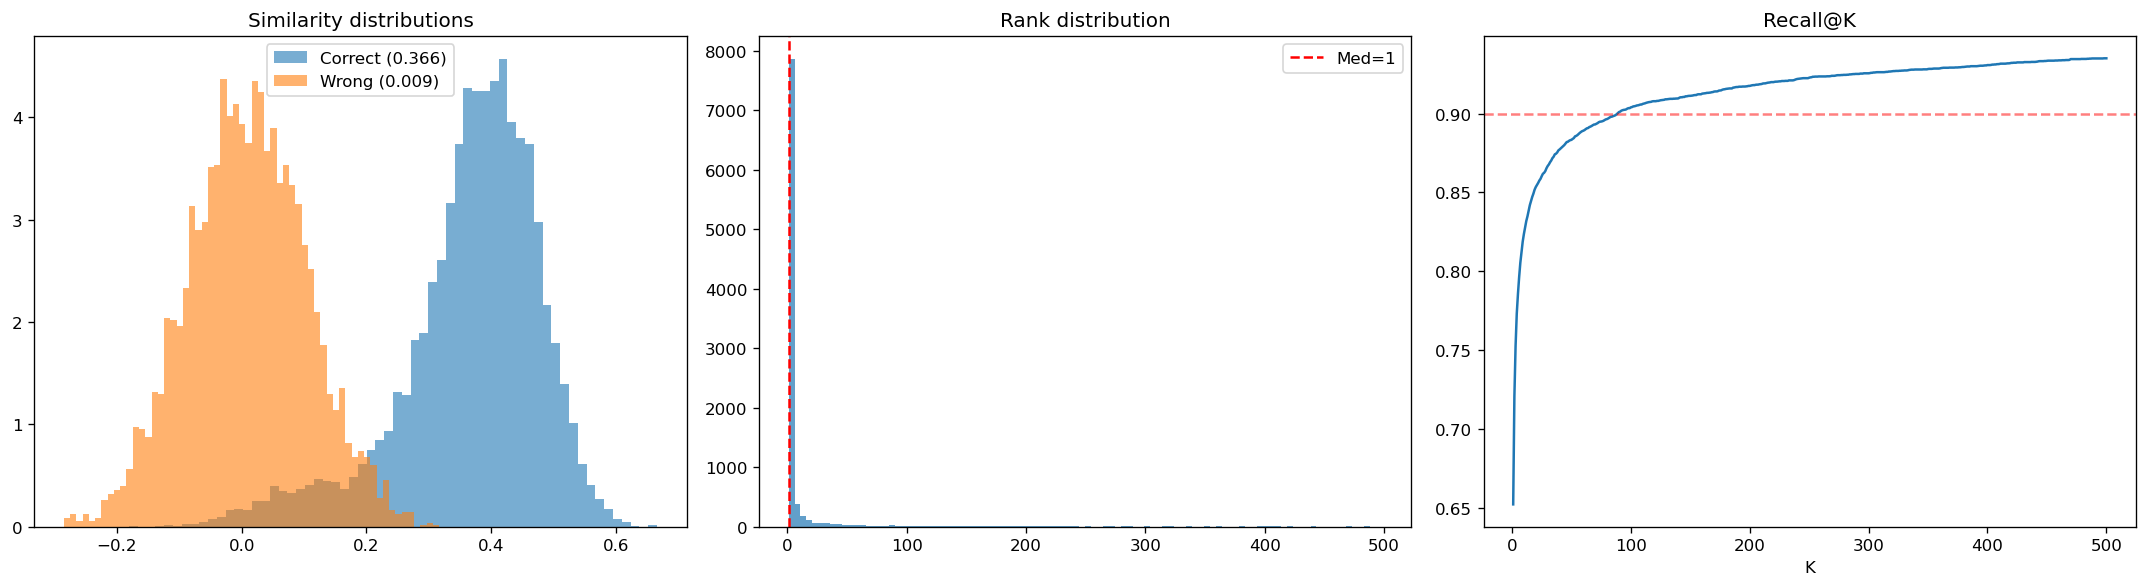

In [ ]:
# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Similarity distributions
correct_sims = sim_mat[np.arange(N), true_mapping]
wrong_sims = np.array([sim_mat[i, np.random.choice([j for j in range(N) if j != i])] for i in range(min(5000, N))])
axes[0].hist(correct_sims, bins=60, alpha=0.6, label=f'Correct ({correct_sims.mean():.3f})', density=True)
axes[0].hist(wrong_sims, bins=60, alpha=0.6, label=f'Wrong ({wrong_sims.mean():.3f})', density=True)
axes[0].set_title('Similarity distributions'); axes[0].legend()

# Rank distribution
ranks = np.array([(np.argsort(-sim_mat[i]) == i).argmax() + 1 for i in range(N)])
axes[1].hist(ranks[ranks <= 500], bins=100, alpha=0.7)
axes[1].axvline(np.median(ranks), color='red', ls='--', label=f'Med={np.median(ranks):.0f}')
axes[1].set_title('Rank distribution'); axes[1].legend()

# Recall@K
ks = np.arange(1, 501)
recalls = [(ranks <= k).mean() for k in ks]
axes[2].plot(ks, recalls); axes[2].axhline(0.9, color='red', ls='--', alpha=0.5)
axes[2].set_title('Recall@K'); axes[2].set_xlabel('K')

plt.tight_layout()
plt.savefig(FIG_DIR / "evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# TEST SUBMISSIONS
# ============================================================
# Decide best pipeline from dev results
use_tta = max(tta_results.values()) > max(results.values())

if use_tta:
    print("Using TTA pipeline (better on dev)")
    test_img_final = encode_images_tta(test_paths, model, TTA_N)
else:
    print("Using single-pass pipeline")
    test_img_final = test_img_emb

# Build test similarity
test_sim = np.zeros((N_TEST, N_TEST), dtype=np.float32)
for i in range(0, N_TEST, CHUNK):
    test_sim[i:min(i+CHUNK, N_TEST)] = test_img_final[i:min(i+CHUNK, N_TEST)] @ test_lat_emb.T

# Apply best post-processing
all_dev_results = {**results, **{f"tta_{k}": v for k, v in tta_results.items()}}
best_overall = max(all_dev_results, key=all_dev_results.get)
print(f"Best overall method: {best_overall}")

# Apply corresponding post-processing to test
if 'csls' in best_overall and 'sinkhorn' in best_overall:
    test_processed = sinkhorn_normalize(csls_score(test_sim, k=best_csls_k), n_iters=10)
elif 'csls' in best_overall:
    test_processed = csls_score(test_sim, k=best_csls_k)
elif 'sinkhorn' in best_overall:
    test_processed = sinkhorn_normalize(test_sim, n_iters=10)
elif 'mknn' in best_overall:
    test_processed = mutual_knn_boost(test_sim)
else:
    test_processed = test_sim

# Hungarian matching
print("Hungarian matching...")
r, c = linear_sum_assignment(-test_processed)

# Submission 1: Best method
sub_rows = [{"image_id": test_ids[r[i]], "z_index": c[i] + 1} for i in range(N_TEST)]
sub = pd.DataFrame(sub_rows).sort_values("image_id").reset_index(drop=True)
run_csv = PRED_DIR / "run.csv"
sub.to_csv(run_csv, index=False, header=False)
zip1 = PRED_DIR / "Method1.zip"
with zipfile.ZipFile(zip1, 'w', zipfile.ZIP_DEFLATED) as zf: zf.write(run_csv, "run.csv")
print(f"Method 1 ({best_overall}): {zip1}")

# Submission 2: Raw (safety)
r2, c2 = linear_sum_assignment(-test_sim)
sub2_rows = [{"image_id": test_ids[r2[i]], "z_index": c2[i] + 1} for i in range(N_TEST)]
sub2 = pd.DataFrame(sub2_rows).sort_values("image_id").reset_index(drop=True)
raw_csv = PRED_DIR / "run_raw.csv"
sub2.to_csv(raw_csv, index=False, header=False)
zip2 = PRED_DIR / "Method2_Raw.zip"
with zipfile.ZipFile(zip2, 'w', zipfile.ZIP_DEFLATED) as zf: zf.write(raw_csv, "run.csv")
print(f"Method 2 (raw): {zip2}")

display(sub.head())

Using TTA pipeline (better on dev)


TTA 10/10: 100%|██████████| 157/157 [01:20<00:00,  1.96it/s]


Best overall method: tta_sinkhorn
Hungarian matching...
Method 1 (tta_sinkhorn): /Users/cherubim/Desktop/GAN2/task2_v10_e2e_membank/predictions/Method1.zip
Method 2 (raw): /Users/cherubim/Desktop/GAN2/task2_v10_e2e_membank/predictions/Method2_Raw.zip


,image_id,z_index
0,00001.png,7885
1,00002.png,2045
2,00003.png,9043
3,00004.png,8918
4,00005.png,4470


In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
summary = {
    "device": DEVICE,
    "backbone": BACKBONE,
    "embed_dim": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "temperature": TEMPERATURE,
    "best_epoch": int(ckpt["epoch"]),
    "best_val_top100": float(ckpt["val_top100"]),
    "best_val_top1": float(ckpt["val_top1"]),
    "dev_results": {k: float(v) for k, v in results.items()},
    "tta_results": {k: float(v) for k, v in tta_results.items()},
    "best_method": best_overall,
    "best_dev_accuracy": float(all_dev_results[best_overall]),
}
save_json(summary, RESULTS_DIR / "run_summary.json")
print(json.dumps(summary, indent=2))

{
  "device": "mps",
  "backbone": "convnext_base.fb_in22k_ft_in1k",
  "embed_dim": 256,
  "batch_size": 32,
  "epochs": 40,
  "temperature": 0.05,
  "best_epoch": 19,
  "best_val_top100": 0.1767578125,
  "best_val_top1": 0.0048828125,
  "dev_results": {
    "raw": 0.7561,
    "csls_k5": 0.7561,
    "csls_k10": 0.7561,
    "csls_k20": 0.7561,
    "sinkhorn_5": 0.758,
    "sinkhorn_10": 0.758,
    "sinkhorn_20": 0.758,
    "mknn_k5_b0.3": 0.6617,
    "mknn_k10_b0.5": 0.6275,
    "mknn_k20_b0.5": 0.6896,
    "csls_sinkhorn": 0.7586
  },
  "tta_results": {
    "raw": 0.8704,
    "csls": 0.8704,
    "sinkhorn": 0.872
  },
  "best_method": "tta_sinkhorn",
  "best_dev_accuracy": 0.872
}
